#### Objective:

*   Use Logistic Regression for classification
*   Preprocess data for modeling
*   Implement Logistic regression on hypothetical data for customer churn of a telecommunication company.






In [10]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss

In [11]:
# load the dataset
df = pd.read_csv("ChurnData.csv")
df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,cardten,voice,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,20.75,0.0,15.25,35.7,42.00,211.45,125.0,1.0,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,0.00,0.0,0.00,0.0,288.80,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,0.00,0.0,0.00,0.0,157.05,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,45.00,50.1,23.25,64.9,239.55,1873.05,880.0,1.0,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,22.00,0.0,23.75,0.0,47.45,166.10,145.0,1.0,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [12]:
# columns to incorporate in the model
df = df[['tenure', 'age', 'address', 'income', 'ed', 'employ', 'equip', 'churn']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tenure   200 non-null    float64
 1   age      200 non-null    float64
 2   address  200 non-null    float64
 3   income   200 non-null    float64
 4   ed       200 non-null    float64
 5   employ   200 non-null    float64
 6   equip    200 non-null    float64
 7   churn    200 non-null    float64
dtypes: float64(8)
memory usage: 12.6 KB


In [13]:
df.describe()

,tenure,age,address,income,ed,employ,equip,churn
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000,200.000000
mean,35.505000,41.165000,11.650000,75.130000,2.82500,10.22500,0.425000,0.290000
std,21.640971,13.076803,10.158419,128.430468,1.28555,8.95743,0.495584,0.454901
min,1.000000,19.000000,0.000000,9.000000,1.00000,0.00000,0.000000,0.000000
25%,16.750000,31.000000,3.000000,31.000000,2.00000,3.00000,0.000000,0.000000
50%,33.500000,40.000000,9.000000,48.000000,3.00000,7.50000,0.000000,0.000000
75%,55.250000,51.000000,18.000000,80.000000,4.00000,17.00000,1.000000,1.000000
max,72.000000,76.000000,48.000000,1668.000000,5.00000,44.00000,1.000000,1.000000


In [14]:
# convert churn column from float to int data type
df['churn'] = df["churn"].astype("int")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   tenure   200 non-null    float64
 1   age      200 non-null    float64
 2   address  200 non-null    float64
 3   income   200 non-null    float64
 4   ed       200 non-null    float64
 5   employ   200 non-null    float64
 6   equip    200 non-null    float64
 7   churn    200 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 12.6 KB


In [29]:
# define the feature and y variable
X = df.drop(columns=["churn"]).to_numpy()
y = df["churn"].to_numpy()
X[:10]
print(type(X))

<class 'numpy.ndarray'>


In [16]:
# normalize the features
std_scaler = StandardScaler()
X = std_scaler.fit_transform(X)
X[:10]

array([[-1.13518441, -0.62595491, -0.4588971 ,  0.4751423 ,  1.6961288 ,
        -0.58477841, -0.85972695],
       [-0.11604313, -0.62595491,  0.03454064, -0.32886061, -0.6433592 ,
        -1.14437497, -0.85972695],
       [-0.57928917, -0.85594447, -0.261522  , -0.35227817, -1.42318853,
        -0.92053635, -0.85972695],
       [ 0.11557989, -0.47262854, -0.65627219,  0.00679109, -0.6433592 ,
        -0.02518185,  1.16316   ],
       [-1.32048283, -0.47262854,  0.23191574,  0.03801451, -0.6433592 ,
         0.53441472, -0.85972695],
       [ 1.505318  ,  0.83064562,  0.52797838,  0.35024865, -1.42318853,
         1.54168853, -0.85972695],
       [ 0.3008783 , -0.08931261, -0.4588971 , -0.29763719, -0.6433592 ,
        -0.24902047,  1.16316   ],
       [-1.22783362, -1.54591314, -1.05102238, -0.45375426, -0.6433592 ,
        -0.92053635, -0.85972695],
       [-0.02339392,  0.67731925,  1.41616631,  0.50636572, -0.6433592 ,
         1.2059306 , -0.85972695],
       [ 0.62515053,  0.7539

In [36]:
# split the dataset into training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape: ", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape: ", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape:  (160, 7)
X_test shape:  (40, 7)
y_train shape:  (160,)
y_test shape:  (40,)


In [37]:
# train the model
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

LogisticRegression()

In [38]:
# predict the y variable
y_predict = classifier.predict(X_test)
y_predict[:10]

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0])

In [39]:
# get the prediction probabilites
# first column denotes the probability belonging to class 0 and second column
# implies the probability of belonging to class 1
y_predict_proba = classifier.predict_proba(X_test)
y_predict_proba[:10]

array([[0.52554605, 0.47445395],
       [0.2035269 , 0.7964731 ],
       [0.78076287, 0.21923713],
       [0.67866244, 0.32133756],
       [0.82962979, 0.17037021],
       [0.30385059, 0.69614941],
       [0.9803522 , 0.0196478 ],
       [0.53650241, 0.46349759],
       [0.5275321 , 0.4724679 ],
       [0.8857783 , 0.1142217 ]])

In [40]:
# evaluate the model
log_loss_value = log_loss(y_test, y_predict_proba)
print("Log Loss value", log_loss_value)

Log Loss value 0.4181681218231804


employ    -0.083248
tenure    -0.029432
age       -0.024953
income     0.001148
address    0.022371
ed         0.258652
equip      0.658262
dtype: float64


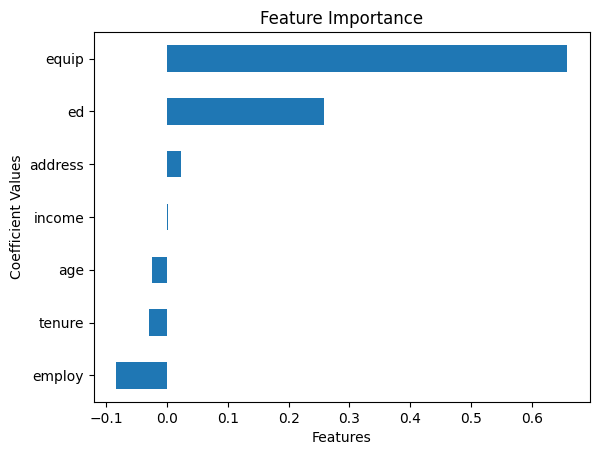

In [55]:
# effectiveness of each feature in classification using bar chart
coefficients = pd.Series(classifier.coef_[0], index=df.columns[:-1]).sort_values()
coefficients.plot(kind='barh')
plt.xlabel("Features")
plt.ylabel("Coefficient Values")
plt.title("Feature Importance")
print(coefficients)